В рамках данного пункта необходимо использовать более сложную модель для решения задачи, оптимизировать гиперпараметры и оценить ее качество.



# Бибилиотеки

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [22]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [23]:
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import shap

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

In [25]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [9]:
!pip install --quiet optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 13.0 MB/s eta 0:00:00


In [20]:
import optuna

# Предобработка

In [29]:
# Подготовка данных
numeric_features = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
categorical_features = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
target = 'G3'

кодирование категориальных признаков

In [30]:
for col in data.columns:
    if data[col].dtype == 'object':
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])

In [31]:
for col in categorical_features:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

# Выбрана более сложная ML-модель - 1 балл


In [18]:
data = pd.read_csv('/content/drive/MyDrive/Фтми/2 курс/ОП и ПМО/student-mat.csv')

Градиентный бустинг в качестве модели для предсказания итоговой оценки G3 учащихся. Это мощная модель, которая хорошо подходит для задач регрессии и может обрабатывать как числовые, так и категориальные данные.

Встроенный выбор признаков - алгоритм сам оценивает важность переменных, упрощая интерпретацию модели.  

Улавливает сложные взаимосвязи автоматически, т.е. способен обнаруживать нелинейные зависимости без ручной генерации признаков.  

Устойчивость к оверфитингу - современные реализации (XGBoost, LightGBM, CatBoost) используют регуляризацию для эффективной борьбы с переобучением.  

In [32]:
# Выборка
X = data.drop(target, axis=1)
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
param_grid = {
'n_estimators': [100, 200],
'max_depth': [None, 10, 20, 30],
'min_samples_split': [2, 5, 10],
}

# Произведен подбор гиперпараметров с scikit-learn методами на кросс-валидации - 2 балла


n_estimators - количество деревьев, в случае градиентного бустинга каждое дерево обучается на ошибках предыдущих деревьев.

learning_rate - насколько сильно каждое дерево влияет на итоговую модель

max depth - глубина дерева

min sample split - минимальное количество образцов, необходимых для разделения узла. Если количество образцов в узле меньше этого значения, узел не будет разделен. Это помогает предотвратить создание слишком сложных деревьев.

Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Среднеквадратичная ошибка: 3.7504109110334745


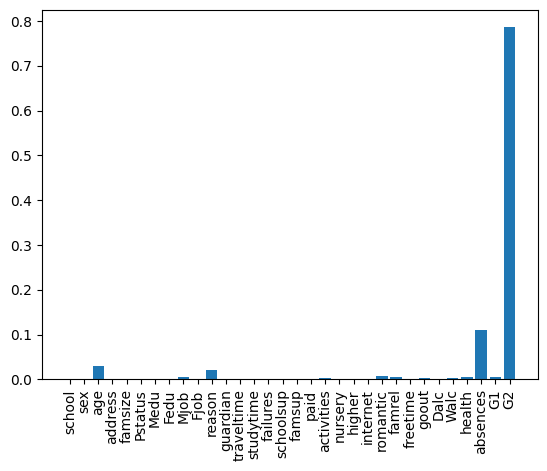

In [44]:
# Задание сетки параметров для подбора
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV для подбора гиперпараметров
grid_search = GridSearchCV(GradientBoostingRegressor(random_state=42),
                           param_grid, cv=3, scoring='neg_mean_squared_error')

grid_search.fit(X_train, y_train)

# Лучшие параметры
print(f"Лучшие параметры: {grid_search.best_params_}")

# Обучение модели с лучшими параметрами
best_gbr = GradientBoostingRegressor(**grid_search.best_params_, random_state=42)
best_gbr.fit(X_train, y_train)

# Прогнозирование на тестовой выборке
y_pred = best_gbr.predict(X_test)

# Оценка качества модели
mse = mean_squared_error(y_test, y_pred)
print(f'Среднеквадратичная ошибка: {mse}')

# Визуализация важности признаков
feature_importances = best_gbr.feature_importances_
plt.bar(X.columns, feature_importances)
plt.xticks(rotation=90)
plt.show()

# Произведен подбор гиперпараметров с optuna на кросс-валидации - 3 балла


n_splits=5 означает, что данные будут разбиты на 5 частей (фолдов).

shuffle=True перемешивает данные перед разбивкой, что важно для предотвращения систематических смещений

In [39]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'random_state': 42 # Важно для воспроизводимости
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    mse_scores = []
    for train_index, val_index in kf.split(X_train):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
        model = GradientBoostingRegressor(**params)
        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val_fold)
        mse = mean_squared_error(y_val_fold, y_pred)
        mse_scores.append(mse)
    return np.mean(mse_scores)

In [40]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

best_params = study.best_params
print(f"Лучшие параметры: {best_params}")

[I 2025-10-27 12:12:55,438] A new study created in memory with name: no-name-cfc0c339-af91-4b90-889b-d62871d6a317
[I 2025-10-27 12:12:58,082] Trial 0 finished with value: 2.041363662142884 and parameters: {'n_estimators': 264, 'learning_rate': 0.018437670289709766, 'max_depth': 7, 'min_samples_split': 7, 'min_samples_leaf': 5}. Best is trial 0 with value: 2.041363662142884.
[I 2025-10-27 12:13:00,351] Trial 1 finished with value: 2.2296055977082907 and parameters: {'n_estimators': 286, 'learning_rate': 0.05629811119504659, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 3}. Best is trial 0 with value: 2.041363662142884.
[I 2025-10-27 12:13:04,564] Trial 2 finished with value: 2.0664240833030787 and parameters: {'n_estimators': 408, 'learning_rate': 0.07943328495601025, 'max_depth': 6, 'min_samples_split': 3, 'min_samples_leaf': 5}. Best is trial 0 with value: 2.041363662142884.
[I 2025-10-27 12:13:06,327] Trial 3 finished with value: 2.404683654147213 and parameters: {'n_es

Лучшие параметры: {'n_estimators': 467, 'learning_rate': 0.01714072876407235, 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 5}


# Выбранная модель обучена с лучшими подобранными значениями гиперпараметров - 2 балла


In [41]:
# Обучение модели с лучшими параметрами
best_model = GradientBoostingRegressor(**best_params, random_state=42)
best_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.01714072876407235, max_depth=7,
                          min_samples_leaf=5, min_samples_split=10,
                          n_estimators=467, random_state=42)

# Произведено измерение качества на отложенной выборке с использованием ранее выбранной метрики - 1 балл


In [42]:
# Оценка качества на тестовой выборке
y_pred_test = best_model.predict(X_test)
mse_test = mean_squared_error(y_test, y_pred_test)
print(f"MSE на тестовой выборке: {mse_test}")

MSE на тестовой выборке: 4.059812938905978


# Получена интерпретация построенной модели, включая визуализации (коэффициенты/permutation importances/shap и тд) - 4 баллов


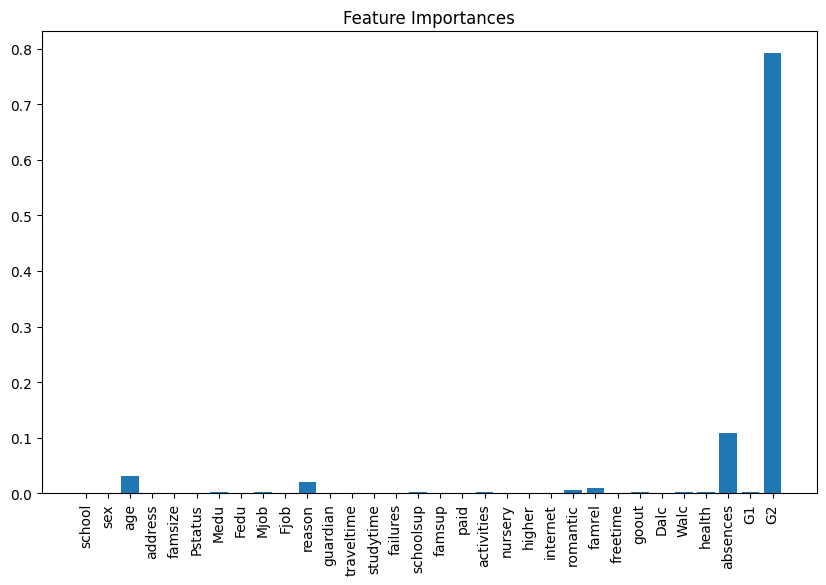

In [43]:
feature_importances = best_model.feature_importances_
feature_names = X.columns
plt.figure(figsize=(10, 6))
plt.bar(feature_names, feature_importances)
plt.xticks(rotation=90)
plt.title('Feature Importances')
plt.show()

# Приведено экспертное мнение о полученной интерпретации (вы, как эксперт в предметной области, можете оценить адекватность признаков и решений, принимаемых моделью, и выразить свое мнение в 1-2 предложении) - 4 баллов

Полученные признаки немного отличаются от тех, которые были предположены в первой лабораторной по матрице корреляции и здесь следует обратить внимание на то, что корреляции слабые (кроме, G2)

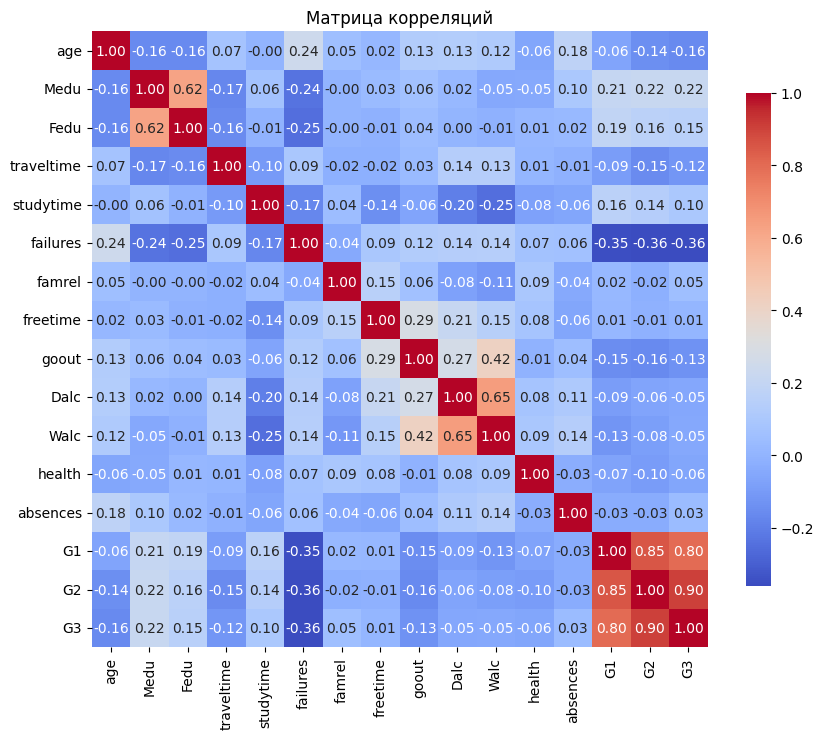

Напомню, что в предыдущей лабораторной работе ошибка составляла 1,5 балла.

***Однако модель с подбором гиперпараметров показала себя в 3 раза менее точно. И это может быть связано с тем, что в этом датасете признаки обладают слабой корреляций с итоговой оценкой. Поэтому более простая модель может работать лучше.***